# Reading, display, comparing, and fitting circuits to transcriptome time course data

This notebook shows how to use Python and dinkum to read in and use transcriptome time course data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import dinkum
from dinkum.vfg import Gene, Receptor, Ligand
from dinkum.vfn import Tissue
from dinkum import vfg, vfn

from dinkum.display import MultiTissuePanel, tc_record_activity
from dinkum.vfg2 import (Growth, Decay, LinearCombination, GeneTimecourse, LogisticActivator, run_lmfit,
                         LogisticRepressor, calc_response_1d, calc_response_2d, LogisticMultiRepressor)


import numpy as np
from itertools import chain

## Read gene time courses in from `TableS1.csv`

This data is from [Feuda, 2022](https://journals.biologists.com/bio/article/11/9/bio059216/276353).

`Table3.xlsx` contains gene name translation information, but not in a computationally usable format :(.

In [2]:
# read data
expr_df = pd.read_csv('TableS1.csv')
expr_df.rename(columns={"Gene Symbol": "gene"}, inplace=True)
expr_df = expr_df.set_index("gene")

In [3]:
# reorganize data into columns by gene name
column_map = {}
for i in range(0, 74):
    old_name = f'{i}hpf'
    new_name = i
    column_map[old_name] = new_name

expr_df.rename(columns=column_map, inplace=True)
expr_df = expr_df.transpose()
expr_df

gene,ascl3l,mllt3,LOC575350,alx1,alx1l,LOC115922992,tfap4,arnt2,drgx,ash1l,...,LOC586893,foxj3,nsd1,xbp1l,yy1,prdm14,LOC100891209,gfi1,LOC764243,zic1
0,1,785,81,0,1,0,11,54,0,55,...,4156,4539,948,1001,1109,0,0,1,59,0
2,1,818,91,0,1,0,9,40,0,41,...,4257,4646,853,948,1166,0,0,0,66,0
4,0,852,69,0,0,5,6,50,0,47,...,4303,4524,838,937,1130,0,0,0,89,0
6,0,794,85,82,1,5,17,51,0,38,...,3638,4750,836,689,1146,0,6,1,96,0
8,0,693,64,385,0,0,78,46,0,24,...,1959,4288,749,384,1044,0,33,0,200,36
10,0,677,33,816,0,0,193,47,0,15,...,831,3255,610,310,1079,0,50,0,312,72
12,0,418,0,1031,0,0,310,18,0,5,...,417,2087,208,271,926,0,87,0,446,229
14,0,267,0,679,0,0,682,29,0,42,...,215,1734,67,470,945,0,48,6,467,348
16,2,216,3,440,4,0,887,28,0,116,...,126,1867,57,1073,1049,0,63,64,408,346
18,23,304,0,493,11,0,836,70,0,237,...,36,2031,56,1398,898,0,62,342,369,493


In [4]:
# index the data by timepoint
expr_df.index = expr_df.index.rename('timepoint')

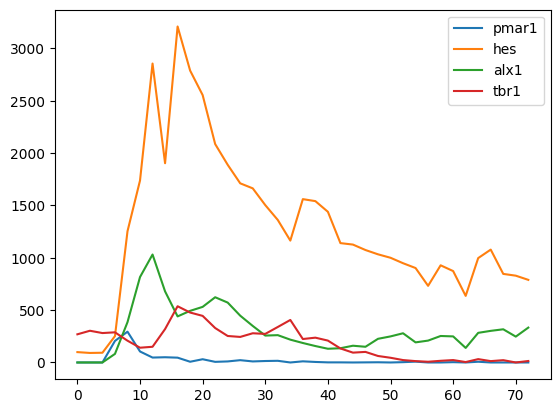

In [5]:
# show some plots, with appropriate renaming of genes.
plt.plot(expr_df.index, expr_df.LOC115926368, label='pmar1')
plt.plot(expr_df.index, expr_df.LOC592057, label='hes')
plt.plot(expr_df.index, expr_df.alx1, label='alx1')
plt.plot(expr_df.index, expr_df.tbr1, label='tbr1')
#plt.plot(expr_df.index, expr_df.ets1, label='ets1')
plt.legend(loc='upper right')

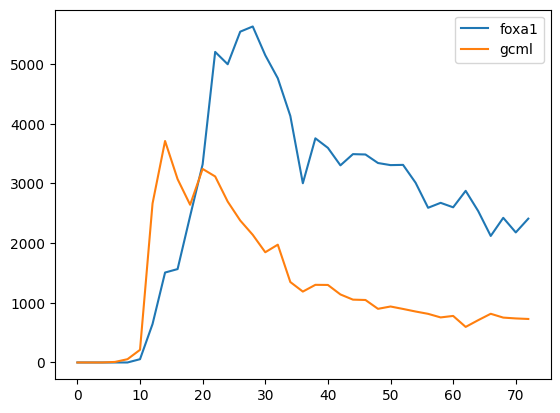

In [6]:
# zoom in on foxa1 and gcm (gcml), which per Revilla-i-Domingo et al, 2007, https://pubmed.ncbi.nlm.nih.gov/17636127/,
# are both regulated by delta ligand/Su(H) cofactor.
plt.plot(expr_df.index, expr_df.foxa1, label='foxa1') # 
plt.plot(expr_df.index, expr_df.gcml, label='gcml')
plt.legend(loc='upper right')

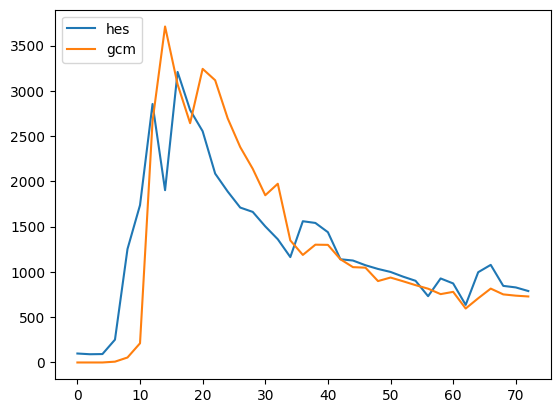

In [7]:
# here, let's compare hes timecourse to gcm. 
plt.plot(expr_df.index, expr_df.LOC592057, label='hes')
plt.plot(expr_df.index, expr_df.gcml, label='gcm')

plt.legend(loc='upper left')

## Use dinkum to visualize time courses

We can use the `GeneTimecourse` activator to load in time course information and display gene time courses with it.

Here, `GeneTimecourse` takes `values` as a list of expresison levels, and scales it to [0, 100].

initializing: dinkum v0.5.0
start=1 stop=36


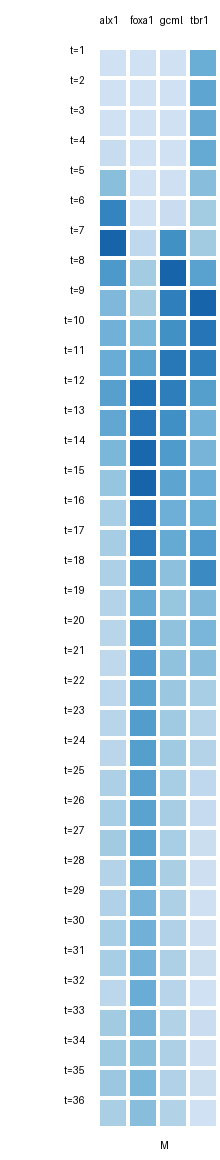

In [8]:
dinkum.reset()

alx1 = Gene(name='alx1')
tbr1 = Gene(name='tbr1')
foxa1 = Gene(name='foxa1')
gcml = Gene(name='gcml')
m = Tissue(name='M')

# load the time points into the internal dinkum structure, for given tissue
for g in (alx1, tbr1, foxa1, gcml):
    g.custom2(GeneTimecourse(start_time=1, tissue=m, values=list(expr_df[g.name])))

# NOTE: 72 hrs every 2 hrs => 36 time points
display, level_df, active_df = dinkum.run_and_display_df(start=1, stop=36)
display

We can also use dinkum-output data frames to display with matplotlib:

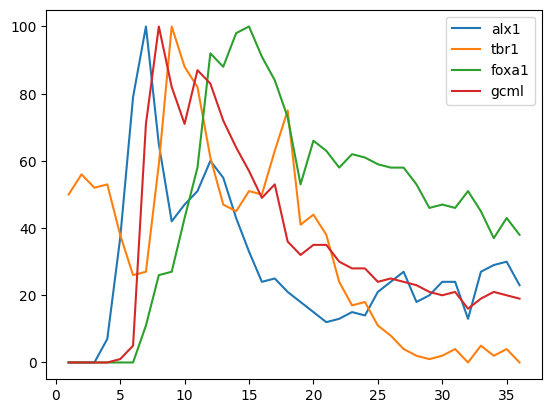

In [9]:
plt.plot(level_df.index, level_df.alx1, label='alx1')
plt.plot(level_df.index, level_df.tbr1, label='tbr1')
plt.plot(level_df.index, level_df.foxa1, label='foxa1')
plt.plot(level_df.index, level_df.gcml, label='gcml')
plt.legend()

## Can we fit two time courses to each other?

Can we fit hes to the gcm time course? This is not actually biologically real - 
hes and gcm are co-regulated by an unknown positive factor - but let's see if
we can do it anyway.

initializing: dinkum v0.5.0
start=1 stop=37
fit message: Fit succeeded.
fit values:
	fit_gcm_whes: fit=0.972854227252256 (was: 1)
start=1 stop=36
[np.float64(0.972854227252256)]


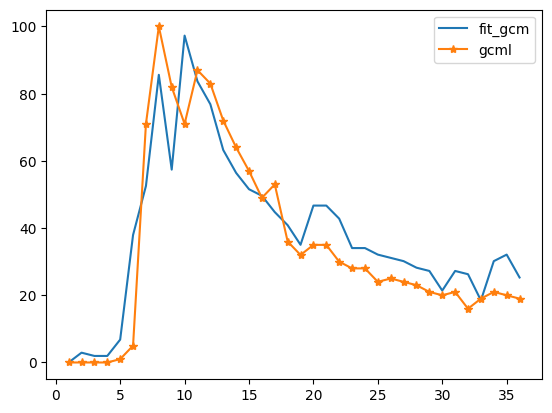

In [10]:
dinkum.reset()

# define the genes
alx1 = Gene(name='alx1')
tbr1 = Gene(name='tbr1')
foxa1 = Gene(name='foxa1')
gcml = Gene(name='gcml')
m = Tissue(name='M')

# load the time points into the internal dinkum structure, for given tissue
for g in (alx1, tbr1, foxa1, gcml):
    g.custom2(GeneTimecourse(start_time=1, tissue=m, values=list(expr_df[g.name])))

# hes is LOC592057...
hes = Gene(name='hes')
hes_tc = GeneTimecourse(start_time=1, tissue=m, values=list(expr_df['LOC592057']))
hes.custom2(hes_tc)

# set up a `fit_gcm` gene that is activated by a weighted version of the `hes` time course.
fit_gcm = Gene(name='fit_gcm')
fit_weights = LinearCombination(gene_names=['hes'])
fit_gcm.custom2(fit_weights)

# now, run a fit, where the values to fit things to are from the `hes_tc` gene.
run_lmfit(1, 37, hes_tc.values, fit_genes=[fit_gcm])

# now, display!
display, level_df, active_df = dinkum.run_and_display_df(start=1, stop=36)

plt.plot(level_df['fit_gcm'], label='fit_gcm')
plt.plot(level_df['gcml'], '*-', label='gcml')
#plt.plot(level_df['hes'], label='hes')

plt.legend()
print(fit_weights.weights)

initializing: dinkum v0.5.0
start=1 stop=37
fit message: Fit succeeded.
fit values:
	fit_foxa1_whes: fit=0.8639335975295914 (was: 1)
start=1 stop=36
[np.float64(0.8639335975295914)]


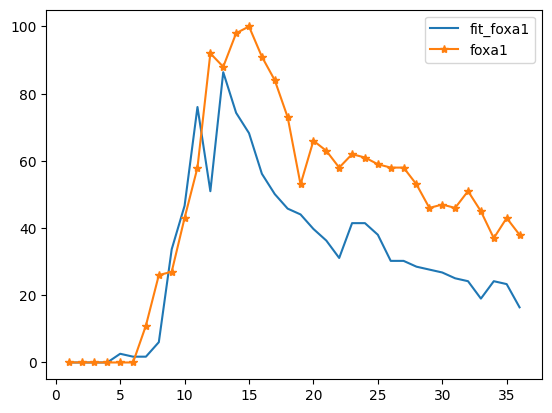

In [11]:
# do the same fit for foxa1
dinkum.reset()

alx1 = Gene(name='alx1')
tbr1 = Gene(name='tbr1')
foxa1 = Gene(name='foxa1')
gcml = Gene(name='gcml')
m = Tissue(name='M')

# load the time points into the internal dinkum structure, for given tissue
for g in (alx1, tbr1, foxa1, gcml):
    g.custom2(GeneTimecourse(start_time=1, tissue=m, values=list(expr_df[g.name])))

# hes is LOC592057...
hes = Gene(name='hes')
hes_tc = GeneTimecourse(start_time=1, tissue=m, values=list(expr_df['LOC592057']))
hes.custom2(hes_tc)

# let's see if we can fit foxa1 to hes (hes activates foxa1, too)...
fit_foxa1 = Gene(name='fit_foxa1')
fit_weights = LinearCombination(gene_names=['hes'], delay=4)
fit_foxa1.custom2(fit_weights)

run_lmfit(1, 37, hes_tc.values, fit_genes=[fit_foxa1])

# NOTE: 72 hrs every 2 hrs => 36 time points
display, level_df, active_df = dinkum.run_and_display_df(start=1, stop=36)

plt.plot(level_df['fit_foxa1'], label='fit_foxa1')
plt.plot(level_df['foxa1'], '*-', label='foxa1')
#plt.plot(level_df['hes'], label='hes')

plt.legend()
print(fit_weights.weights)